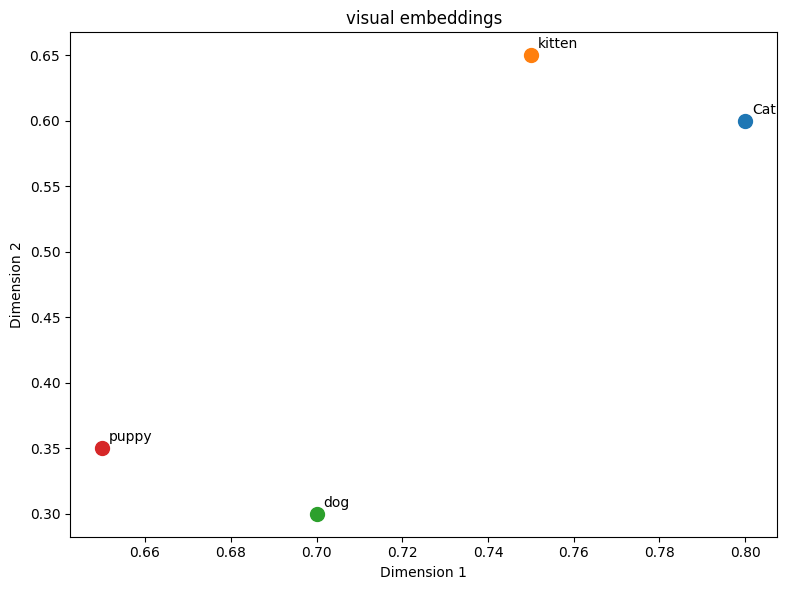

In [1]:
import numpy as np
import matplotlib.pyplot as plt

word_embedded = {
    "Cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog":[0.7,0.3],
    "puppy":[0.65,0.35]
}
# matplotlib_visualization
fig, ax = plt.subplots(figsize=(8, 6))
for word, coords in word_embedded.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), textcoords='offset points')
    
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_title("visual embeddings")
plt.tight_layout()
plt.show()

In [2]:
## Measuring similarity
def cosine_similarity(vec1,vec2):
    dot_product = np.dot(vec1,vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    return dot_product/(norm_a * norm_b)

In [3]:
# compute cosine similarity between two embeddings (e.g., 'puppy' and 'dog')
vec1 = word_embedded['puppy']
vec2 = word_embedded['dog']
sim = cosine_similarity(vec1, vec2)
print(sim)

0.9960377053144617


## Embeddings with HuggingFace


In [4]:
from langchain_huggingface import HuggingFaceEmbeddings
embedding = HuggingFaceEmbeddings(
    model="sentence-transformers/all-MiniLM-L6-v2",
    #cache_folder="./models"
)
embedding

d:\RAG--\RAG_Processing\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [5]:
## cosine similarity
text =" This is a sentence-transformers model: It maps sentences & paragraphs to a 384 dimensional dense vector space "

embedding_text = embedding.embed_query(text)
print(f"length of embedding '{len(embedding_text)}'")
print(embedding_text)


length of embedding '384'
[-0.01881374418735504, -0.020380647853016853, 0.0075699989683926105, 0.017595184966921806, -0.021706221625208855, 0.09158483147621155, -0.01515372283756733, -0.020673882216215134, 0.05082305148243904, -0.02928171306848526, 0.0513467900454998, 0.014276791363954544, 0.03705278038978577, 0.05018283799290657, -0.03165530040860176, 0.0660189762711525, -0.014291267842054367, 0.05851736664772034, -0.10088402777910233, -0.0606527142226696, 0.07910566031932831, 0.12393401563167572, -0.01008859183639288, -0.012737005949020386, 0.0040790303610265255, 0.13291078805923462, -0.008574333973228931, -0.08361421525478363, -0.008175774477422237, -0.04906095191836357, -0.004106911830604076, 0.021289415657520294, -0.008004198782145977, 0.11352952569723129, -0.021950989961624146, 0.03421344980597496, -0.02337532490491867, -0.019288521260023117, 0.02083035185933113, -0.013132607564330101, 0.023212987929582596, -0.0016969116404652596, 0.009568078443408012, 0.07159701734781265, 0.0983

In [23]:
documents=[
   " Hybrid Search: Combine embeddings (semantic similarity) with keyword search for precision.",
   
   " Multimodal Embeddings: Represent text + images together (useful for multimodal RAG).",
   
    "Self-RAG: The model evaluates its own retrieval quality and adjusts queries.",

    "Adaptive RAG: Dynamically changes chunk size or retrieval strategy based on query type."
]
query="What is semantic search?"


In [ ]:
def semantic_search(query, documents, embedding, top_k=1):
    
    query_embedding = embedding.embed_query(query)
    doc_embeddings = [embedding.embed_query(doc) for doc in documents]
    
    similarities = []
    
    for i, doc_embedding in enumerate(doc_embeddings):
        similarities_score = cosine_similarity(query_embedding, doc_embedding)
        similarities.append((similarities_score,documents[i]))
        
    similarities.sort(reverse=True)
    return similarities[:top_k]
        

In [25]:
results = semantic_search(query, documents, embedding)
results

[(np.float64(0.48021517097212985),
  ' Hybrid Search: Combine embeddings (semantic similarity) with keyword search for precision.')]

In [ ]:
for score, doc in results:
    print(f"Score: {score:.4f} \nDocument: {doc}\n")
    print(doc)

Score: 0.7125 
Document:  Multimodal Embeddings: Represent text + images together (useful for multimodal RAG).

 Multimodal Embeddings: Represent text + images together (useful for multimodal RAG).


In [36]:
query="Explain multimodal embeddings ?."
results = semantic_search(query, documents, embedding)
results
#for score, doc in results:
print(doc)

 Multimodal Embeddings: Represent text + images together (useful for multimodal RAG).
